In [1]:
import pandas as pd
import ast
import numpy as np


portfolio = pd.read_csv('../data/portfolio.csv')
profile = pd.read_csv('../data/profile.csv') # (17000, 6)
transcript = pd.read_csv('../data/transcript.csv') # (306534, 8)


# 데이터 전처리
- 결측치 처리
    - prf테이블 gender와 income에 2175개 존재
- 이상치 처리
    - age 118세 존재(2175개) / 전체적으로 높은 나이 분포
- 데이터 정제
    - became_member_on 컬럼 datetime으로 변환
    - channels 에서 각각 web, email, mobile, social로 나눌 것인가
- 데이터 파생 변수
    - value 컬럼의 딕셔너리 형태 값을 offer id, offer id + reward, amount로 나눠 파생 변수 생성


In [2]:
# # 쓸모없는 인덱스열 삭제
# portfolio = portfolio.drop(columns=['Unnamed: 0'], errors='ignore')
# profile = profile.drop(columns=['Unnamed: 0'], errors='ignore')
# transcript = transcript.drop(columns=['Unnamed: 0'], errors='ignore')


In [3]:
# 데이터 타입 date형식으로 변환
profile["became_member_on"] = pd.to_datetime(profile["became_member_on"], format="%Y%m%d")


# channels마다 파생변수 생성
portfolio['web'] = portfolio['channels'].astype(str).str.contains('web').astype(int)
portfolio['email'] = portfolio['channels'].astype(str).str.contains('email').astype(int)
portfolio['mobile'] = portfolio['channels'].astype(str).str.contains('mobile').astype(int)
portfolio['social'] = portfolio['channels'].astype(str).str.contains('social').astype(int)

# 기존 channels 컬럼 제거
portfolio = portfolio.drop('channels', axis=1)

In [4]:
# 딕셔너리처럼 생긴 문자열을 진짜 딕셔너리로 변환
transcript['value'] = transcript['value'].apply(ast.literal_eval)

# 딕셔너리의 키 -> 새로운 컬럼
value_df = pd.DataFrame(transcript['value'].tolist())
transcript = pd.concat([transcript, value_df], axis=1)

# offer id를 offer_id로 컬럼명 통일
transcript['offer_id'] = transcript['offer_id'].fillna(transcript['offer id'])

# offer id 컬럼 제거
transcript = transcript.drop('offer id', axis=1)

# value 컬럼 제거
transcript = transcript.drop('value', axis=1)

In [5]:
# profile의 필요없는 Unnamed:0 컬럼 제거
profile = profile.drop('Unnamed: 0', axis=1)

# transcript 기준으로 profile 데이터를 Left Join
merged_df = pd.merge(transcript, profile, left_on='person', right_on='id', how='left')

# 필요 없는 id 컬럼(person과 중복)은 버리기
merged_df = merged_df.drop(columns='id')

In [6]:
display(merged_df.head())
display(merged_df.shape)

,Unnamed: 0,person,event,time,amount,offer_id,reward,gender,age,became_member_on,income
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,F,75,2017-05-09,100000.0
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,118,2017-08-04,NaN
2,2,e2127556f4f64592b11af22de27a7932,offer received,0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,M,68,2018-04-26,70000.0
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,118,2017-09-25,NaN
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,0,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,118,2017-10-02,NaN


(306534, 11)

In [7]:
# # hyeong uk님의 논리를 그대로 번역한 필터링 조건
# is_118_years_old = merged_df['age'] == 118
# is_transaction = merged_df['event'] == 'transaction'

# # 두 조건을 모두 만족하는 교집합 데이터만 뽑아내기
# anomaly_transactions = merged_df[is_118_years_old & is_transaction]

# # 수상한 고객들이 긁은 총 결제 횟수와 누적 금액 확인
# total_count = anomaly_transactions['amount'].count()
# total_spent = anomaly_transactions['amount'].sum()

# print(f"118세 고객들의 총 결제 횟수: {total_count:,}건")
# print(f"118세 고객들의 총 결제 금액: ${total_spent:,.2f}")

In [8]:
# 결측치 처리

# gender의 결측치 'Unknown'으로 채우기 
merged_df['gender'] = merged_df['gender'].fillna('Unknown')


# age의 118을 결측치(NaN)로 바꿔주기 
merged_df['age'] = merged_df['age'].replace(118, np.nan)
# income은 이미 결측치(NaN) 상태

In [9]:
# # gender 필터링
# is_gender_others = merged_df['gender'] == 'O'

# # 두 조건을 모두 만족하는 교집합 데이터만 뽑아내기
# anomaly_transactions2 = merged_df[is_gender_others & is_transaction]

# # 수상한 고객들이 긁은 총 결제 횟수와 누적 금액 확인
# total_count2 = anomaly_transactions2['amount'].count()
# total_spent2 = anomaly_transactions2['amount'].sum()

# print(f"others 고객들의 총 결제 횟수: {total_count2:,}건")
# print(f"others 고객들의 총 결제 금액: ${total_spent2:,.2f}")

In [10]:
# portfolio 테이블도 병합

# portfolio 테이블의 필요없는 인덱스 컬럼 제거
portfolio = portfolio.drop('Unnamed: 0', axis=1)

all_merge_df = pd.merge(
    merged_df,
    portfolio,
    left_on='offer_id',
    right_on='id',
    how='left'
)

all_merge_df = all_merge_df.drop(columns='id')

# reward 컬럼명 변경(명확하게)
all_merge_df = all_merge_df.rename(columns={
    "reward_x": "transcript_reward",
    "reward_y": "portfolio_reward"
})

In [11]:
# offer_id 이름 변경 (쿠폰명_difficulty_reward_duration)
portfolio['offer_name'] = (
    portfolio['offer_type'] + '_' + 
    portfolio['difficulty'].astype(str) + '_' + 
    portfolio['reward'].astype(str) + '_' + 
    portfolio['duration'].astype(str)
)
# id : key, offer_name : value
offer_name_dict = portfolio.set_index('id')['offer_name'].to_dict()
all_merge_df['offer_id'] = all_merge_df['offer_id'].map(offer_name_dict)


# 사람(person)별로 먼저 묶고, 그 안에서 시간(time) 순서대로 오름차순 정렬
all_merge_df = all_merge_df.sort_values(by=['person', 'time', 'Unnamed: 0']) # - Unnamed: 0 순서 추가

In [12]:
all_merge_df

,Unnamed: 0,person,event,time,amount,offer_id,transcript_reward,gender,age,became_member_on,income,portfolio_reward,difficulty,duration,offer_type,web,email,mobile,social
55972,55972,0009655768c64bdeb2e877511632db8f,offer received,168,NaN,informational_0_0_3,NaN,M,33.0,2017-04-21,72000.0,0.0,0.0,3.0,informational,0.0,1.0,1.0,1.0
77705,77705,0009655768c64bdeb2e877511632db8f,offer viewed,192,NaN,informational_0_0_3,NaN,M,33.0,2017-04-21,72000.0,0.0,0.0,3.0,informational,0.0,1.0,1.0,1.0
89291,89291,0009655768c64bdeb2e877511632db8f,transaction,228,22.16,NaN,NaN,M,33.0,2017-04-21,72000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113605,113605,0009655768c64bdeb2e877511632db8f,offer received,336,NaN,informational_0_0_4,NaN,M,33.0,2017-04-21,72000.0,0.0,0.0,4.0,informational,1.0,1.0,1.0,0.0
139992,139992,0009655768c64bdeb2e877511632db8f,offer viewed,372,NaN,informational_0_0_4,NaN,M,33.0,2017-04-21,72000.0,0.0,0.0,4.0,informational,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258361,258361,ffff82501cea40309d5fdd7edcca4a07,transaction,576,14.23,NaN,NaN,F,45.0,2016-11-25,62000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
258362,258362,ffff82501cea40309d5fdd7edcca4a07,offer completed,576,NaN,discount_10_2_7,2.0,F,45.0,2016-11-25,62000.0,2.0,10.0,7.0,discount,1.0,1.0,1.0,0.0
262475,262475,ffff82501cea40309d5fdd7edcca4a07,offer viewed,582,NaN,discount_10_2_7,NaN,F,45.0,2016-11-25,62000.0,2.0,10.0,7.0,discount,1.0,1.0,1.0,0.0
274809,274809,ffff82501cea40309d5fdd7edcca4a07,transaction,606,10.12,NaN,NaN,F,45.0,2016-11-25,62000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 고객별... 기술통계치

C:\Temp\ipykernel_17008\2361409513.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=all_merge_df, x='gender', y='income', palette='pastel')


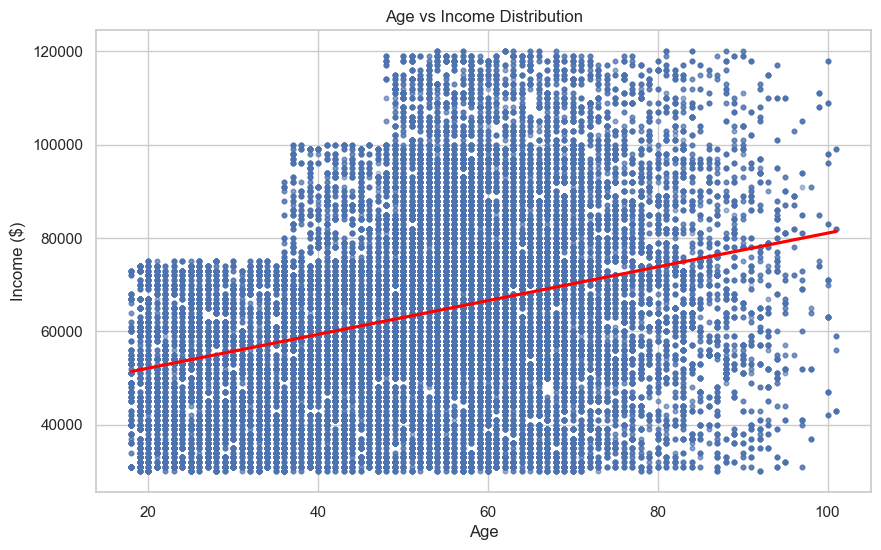

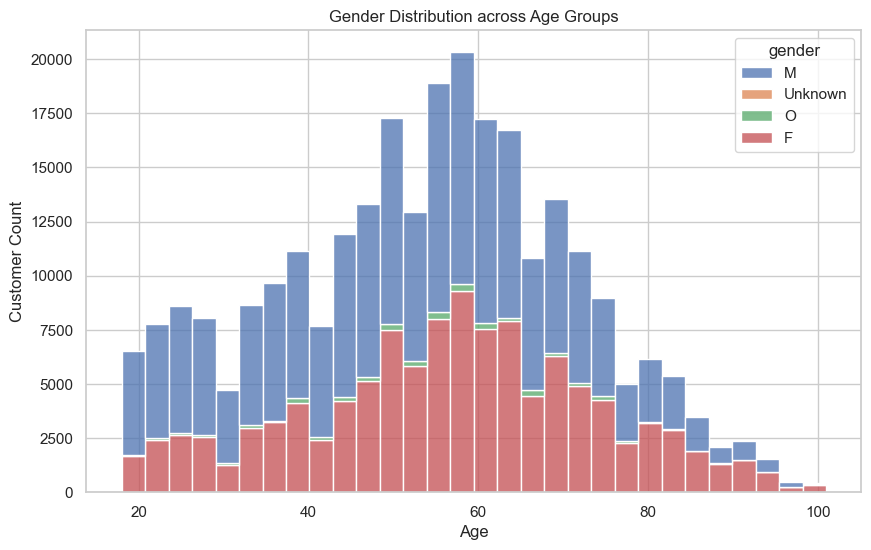

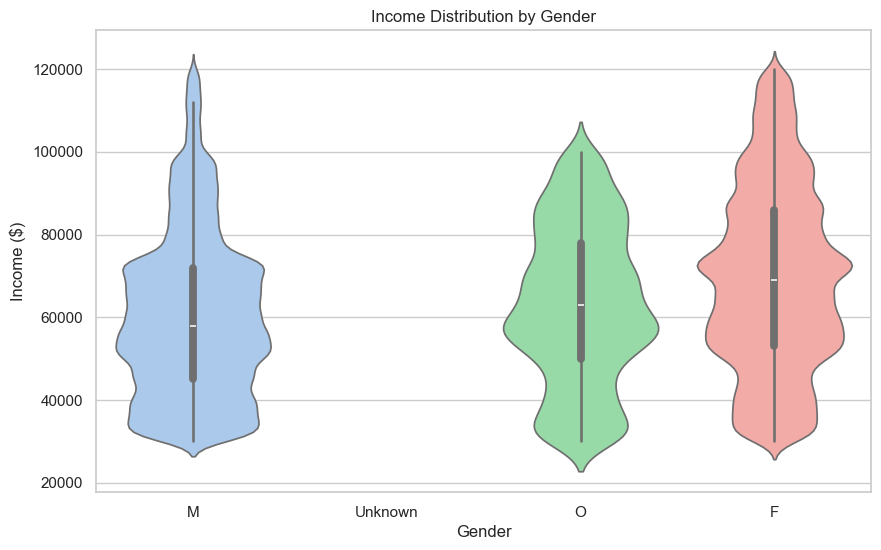

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 스타일 설정
sns.set_theme(style="whitegrid")

# --- 1) 연령별 수입 (Income by Age) ---
# 나이가 많아질수록 수입이 늘어나는 경향(상관관계)이 있는지 확인합니다.
plt.figure(figsize=(10, 6))
sns.regplot(data=all_merge_df, x='age', y='income', 
            scatter_kws={'alpha':0.1, 's':10}, # 투명도를 주어 밀집도 확인
            line_kws={'color':'red'})          # 추세선(회귀선) 추가
plt.title('Age vs Income Distribution')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.savefig('income_by_age.png')

# --- 2) 연령별 성별 분포 (Gender by Age) ---
# 특정 연령대에 남성이나 여성이 더 많이 몰려있는지 확인합니다.
plt.figure(figsize=(10, 6))
sns.histplot(data=all_merge_df, x='age', hue='gender', multiple='stack', bins=30)
plt.title('Gender Distribution across Age Groups')
plt.xlabel('Age')
plt.ylabel('Customer Count')
plt.savefig('gender_by_age.png')

# --- 3) 성별에 따른 수입 분포 (Income by Gender) ---
# 성별 간의 경제적 여력(구매력) 차이를 확인합니다.
plt.figure(figsize=(10, 6))
sns.violinplot(data=all_merge_df, x='gender', y='income', palette='pastel')
plt.title('Income Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Income ($)')
plt.savefig('income_by_gender.png')

#### 가시성 구려서 연령별 소득 시각화 더 만듦

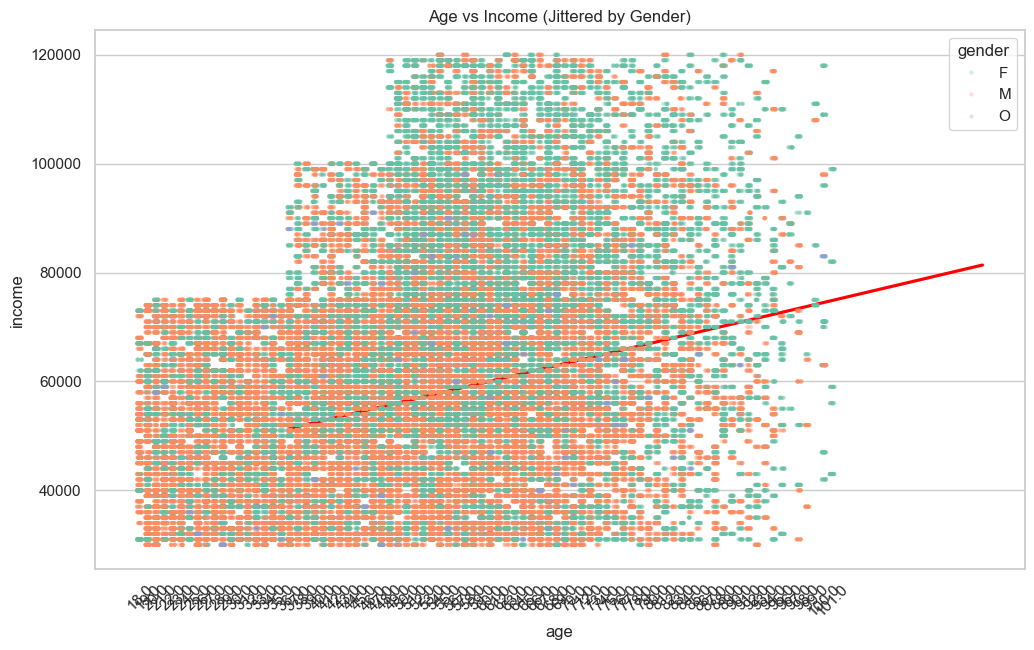

In [14]:
import numpy as np

# 1. 수입에 로그 변환 적용 (수입 격차가 클 때 유용)
# all_merge_df['log_income'] = np.log10(all_merge_df['income'])

plt.figure(figsize=(12, 7))

# stripplot은 점들을 미세하게 흩뿌려주어(jitter) 겹친 정도를 보여줍니다.
sns.stripplot(data=all_merge_df[all_merge_df['age'] < 118], 
              x='age', y='income', hue='gender', 
              jitter=0.3, alpha=0.3, size=3, palette='Set2')

# 추세선은 별도로 그려줍니다.
sns.regplot(data=all_merge_df[all_merge_df['age'] < 118], 
            x='age', y='income', scatter=False, color='red')

plt.title('Age vs Income (Jittered by Gender)')
plt.xticks(rotation=45) # 나이 축이 촘촘할 경우 대비
plt.show()

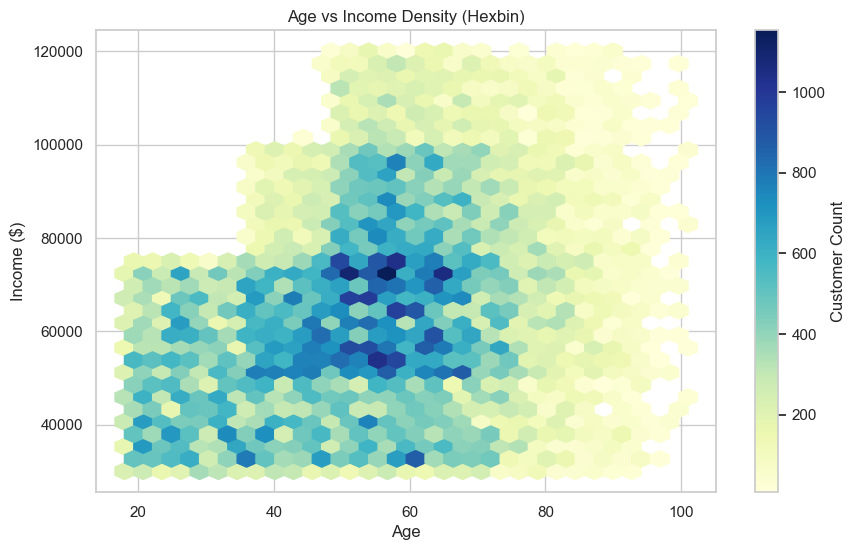

In [15]:
plt.figure(figsize=(10, 6))
# gridsize가 클수록 세밀해집니다.
plt.hexbin(all_merge_df['age'], all_merge_df['income'], 
           gridsize=30, cmap='YlGnBu', mincnt=1)
plt.colorbar(label='Customer Count')
plt.title('Age vs Income Density (Hexbin)')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.show()

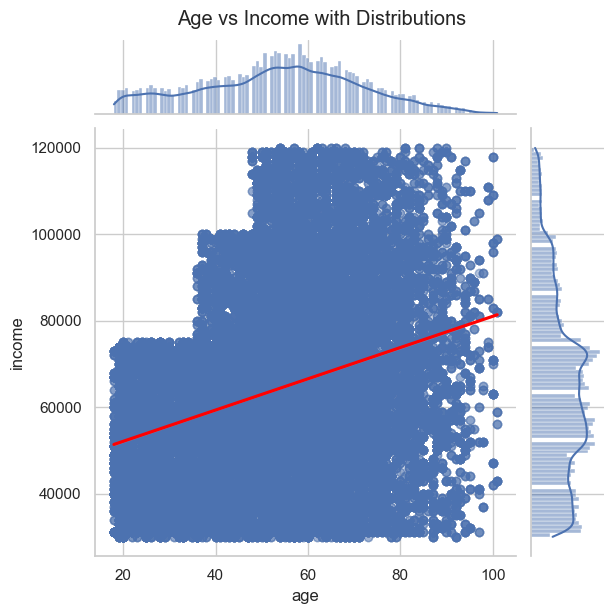

In [16]:
# kind='hex' 혹은 'reg'를 섞어서 사용 가능
g = sns.jointplot(data=all_merge_df[all_merge_df['age'] < 118], 
                  x='age', y='income', kind='reg', 
                  scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
g.fig.suptitle('Age vs Income with Distributions', y=1.02)
plt.show()

In [17]:
# 무엇을 위해 하는 코드인가? -> informational이 아닌 completed와 amount 경우만 선택하는 과정

# 조건 1: 쿠폰 타입이 bogo 이거나(in) discount 인 것
cond_offers = all_merge_df['offer_type'].isin(['bogo', 'discount'])

# 조건 2: 이벤트 종류가 transaction(결제) 인 것
cond_transactions = all_merge_df['event'] == 'transaction'

# 위 두 조건 중 하나라도 만족하는(|) 데이터만 쏙 뽑아서 덮어씌우기
target_df = all_merge_df[cond_offers | cond_transactions].copy()

# 잘 걸러졌는지 눈으로 확인해보기
print(target_df['offer_type'].value_counts(dropna=False))
print(target_df['event'].value_counts(dropna=False))
display(target_df.head())
display(target_df.shape)

offer_type
NaN         138953
bogo         71617
discount     69898
Name: count, dtype: int64
event
transaction        138953
offer received      61042
offer viewed        46894
offer completed     33579
Name: count, dtype: int64


,Unnamed: 0,person,event,time,amount,offer_id,transcript_reward,gender,age,became_member_on,income,portfolio_reward,difficulty,duration,offer_type,web,email,mobile,social
89291,89291,0009655768c64bdeb2e877511632db8f,transaction,228,22.16,NaN,NaN,M,33.0,2017-04-21,72000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153401,153401,0009655768c64bdeb2e877511632db8f,offer received,408,NaN,bogo_5_5_5,NaN,M,33.0,2017-04-21,72000.0,5.0,5.0,5.0,bogo,1.0,1.0,1.0,1.0
168412,168412,0009655768c64bdeb2e877511632db8f,transaction,414,8.57,NaN,NaN,M,33.0,2017-04-21,72000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168413,168413,0009655768c64bdeb2e877511632db8f,offer completed,414,NaN,bogo_5_5_5,5.0,M,33.0,2017-04-21,72000.0,5.0,5.0,5.0,bogo,1.0,1.0,1.0,1.0
187554,187554,0009655768c64bdeb2e877511632db8f,offer viewed,456,NaN,bogo_5_5_5,NaN,M,33.0,2017-04-21,72000.0,5.0,5.0,5.0,bogo,1.0,1.0,1.0,1.0


(280468, 19)

### 연령/성별/소득별 amount 평균 시각화

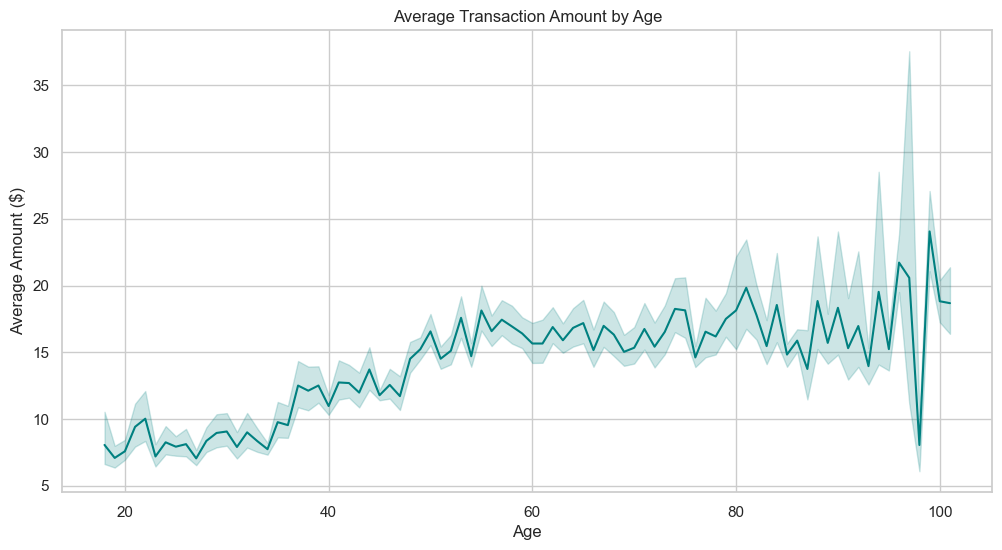

C:\Temp\ipykernel_17008\3457050970.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_trans, x='gender', y='amount', palette='Set3', showfliers=False)


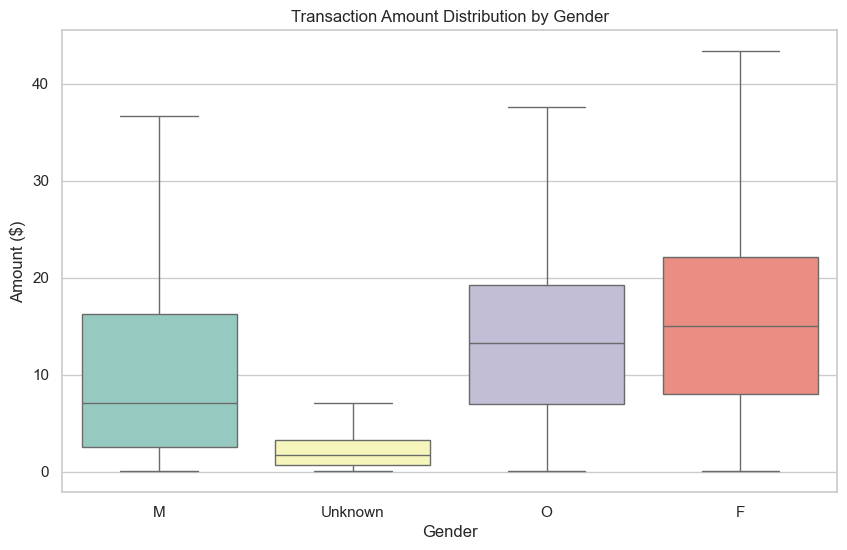

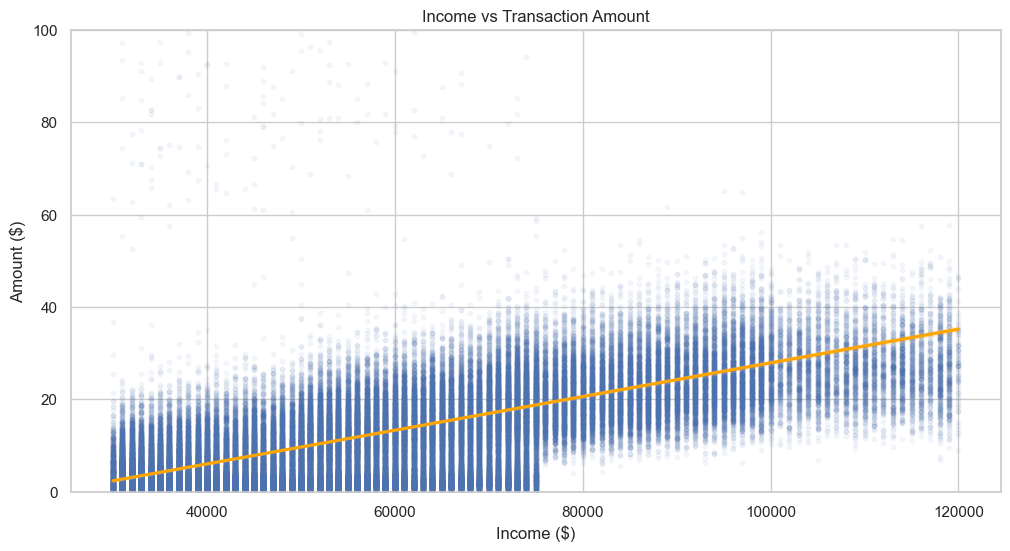

In [18]:
# 1. 결제 데이터만 필터링 (amount가 존재하는 데이터)
df_trans = all_merge_df[(all_merge_df['event'] == 'transaction')].copy()

# 시각화 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif' # 한글 깨짐 방지 설정 필요 시 추가

# --- 1) 연령별 평균 결제 금액 (Amount by Age) ---
# 나이에 따른 결제 패턴의 변화를 선 그래프(Line Plot)로 봅니다.
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trans, x='age', y='amount', color='teal', errorbar=('ci', 95))
plt.title('Average Transaction Amount by Age')
plt.xlabel('Age')
plt.ylabel('Average Amount ($)')
plt.show()

# --- 2) 성별에 따른 결제 금액 분포 (Amount by Gender) ---
# 어떤 성별이 한 번 결제할 때 더 큰 금액을 쓰는지 확인합니다.
plt.figure(figsize=(10, 6))
# 이상치(Outlier)가 너무 크면 boxplot이 찌그러지므로 showfliers=False로 설정하거나 범위를 제한합니다.
sns.boxplot(data=df_trans, x='gender', y='amount', palette='Set3', showfliers=False)
plt.title('Transaction Amount Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Amount ($)')
plt.show()

# --- 3) 소득에 따른 결제 금액 (Amount by Income) ---
# 소득이 높을수록 커피 한 잔에 쓰는 돈도 늘어나는지 확인합니다.
plt.figure(figsize=(12, 6))
# 데이터가 많으므로 lmplot을 써서 추세선과 밀도를 동시에 확인합니다.
sns.regplot(data=df_trans, x='income', y='amount', 
            scatter_kws={'alpha':0.05, 's':10}, line_kws={'color':'orange'})
plt.title('Income vs Transaction Amount')
plt.xlabel('Income ($)')
plt.ylabel('Amount ($)')
# y축 범위를 적절히 제한하여 가시성을 높입니다 (예: 0~100달러)
plt.ylim(0, 100) 
plt.show()

### 연령/성별/평균별 amount 합계 시각화

C:\Temp\ipykernel_17008\552271228.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_sum, x='gender', y='amount', palette='magma')
C:\Temp\ipykernel_17008\552271228.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_bracket_sum = df_trans.groupby('income_bracket')['amount'].sum().reset_index()


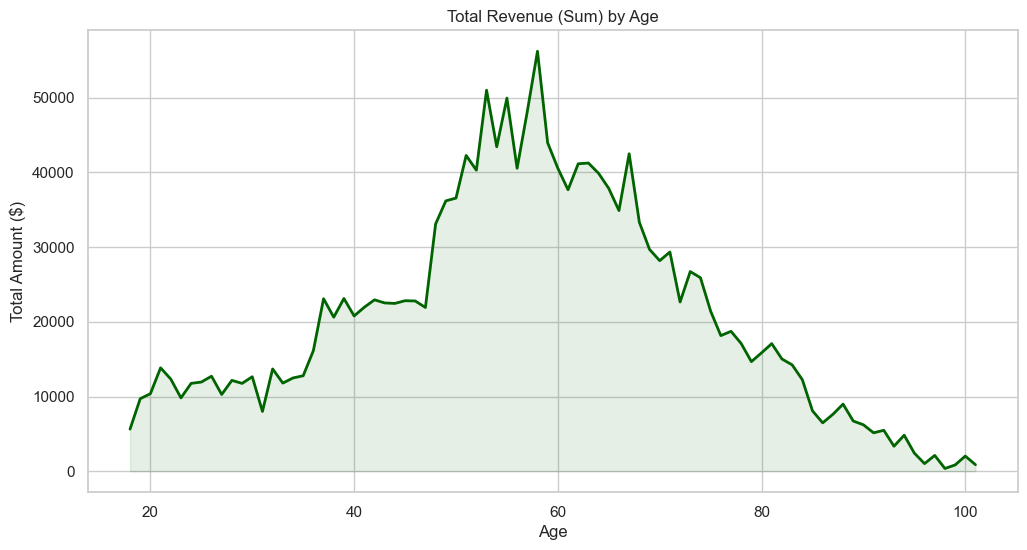

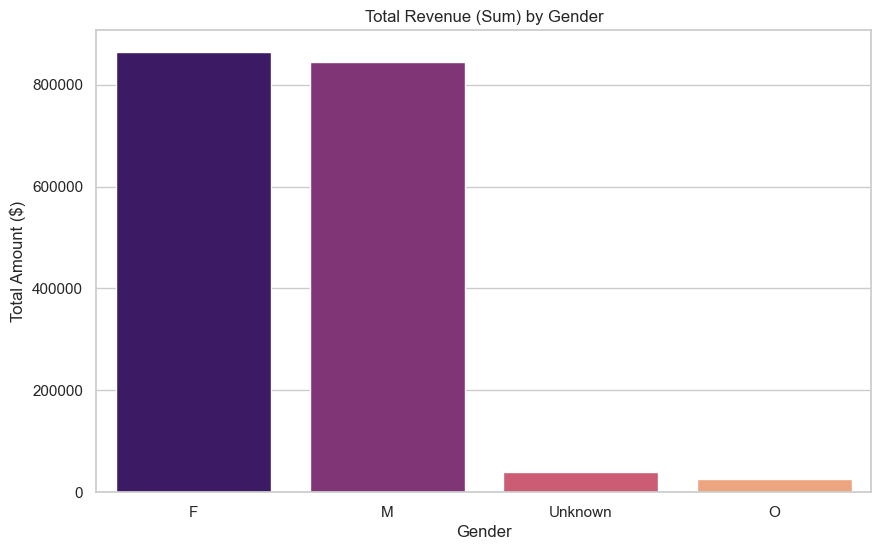

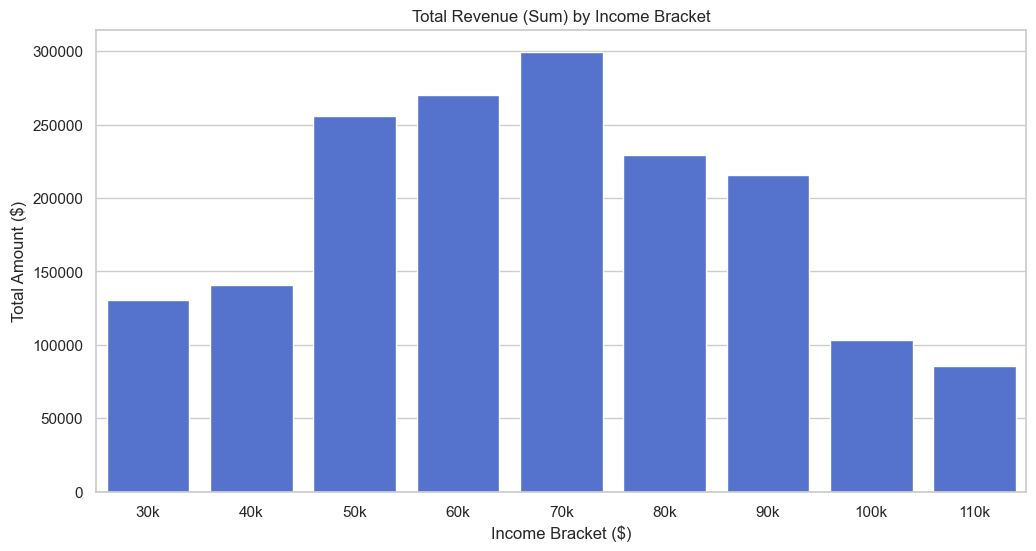

In [19]:
# 시각화 스타일 설정
sns.set_theme(style="whitegrid")

# --- 1) 연령별 매출 합계 (Total Amount by Age) ---
plt.figure(figsize=(12, 6))
# 118세(NaN)를 제외한 연령별 합계 계산
age_sum = df_trans.dropna(subset=['age']).groupby('age')['amount'].sum().reset_index()
sns.lineplot(data=age_sum, x='age', y='amount', color='darkgreen', linewidth=2)
plt.fill_between(age_sum['age'], age_sum['amount'], color='darkgreen', alpha=0.1) # 면적 강조
plt.title('Total Revenue (Sum) by Age')
plt.xlabel('Age')
plt.ylabel('Total Amount ($)')
plt.savefig('total_amount_by_age.png')

# --- 2) 성별 매출 합계 (Total Amount by Gender) ---
plt.figure(figsize=(10, 6))
gender_sum = df_trans.groupby('gender')['amount'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=gender_sum, x='gender', y='amount', palette='magma')
plt.title('Total Revenue (Sum) by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Amount ($)')
plt.savefig('total_amount_by_gender.png')

# --- 3) 소득 구간별 매출 합계 (Total Amount by Income Bracket) ---
# 소득은 연속형이므로 1만 달러 단위로 구간을 나누어(Binning) 합계를 봅니다.
plt.figure(figsize=(12, 6))
# 소득 구간 생성 (30k~120k)
income_bins = range(30000, 130000, 10000)
labels = [f'{i//1000}k' for i in income_bins[:-1]]
df_trans['income_bracket'] = pd.cut(df_trans['income'], bins=income_bins, labels=labels)

income_bracket_sum = df_trans.groupby('income_bracket')['amount'].sum().reset_index()
sns.barplot(data=income_bracket_sum, x='income_bracket', y='amount', color='royalblue')
plt.title('Total Revenue (Sum) by Income Bracket')
plt.xlabel('Income Bracket ($)')
plt.ylabel('Total Amount ($)')
plt.savefig('total_amount_by_income.png')

### 약식 세그먼트 분류

In [43]:
import pandas as pd
import plotly.express as px

# 1. 결제 데이터만 준비
df_trans = all_merge_df[all_merge_df['event'] == 'transaction'].copy()

# --- 전처리 시작 ---

# 2. 성별 결측치(118세 그룹) 처리
df_trans['gender'] = df_trans['gender'].fillna('Unknown')

# 3. 연령대(Age Group) 구간 만들기
# 118세 그룹은 age가 NaN이므로 'Unknown'으로 따로 분류합니다.
age_bins = [0, 19, 29, 39, 49, 59, 69, 79, 120]
age_labels = ['<20s', '20s', '30s', '40s', '50s', '60s', '70s', '80s+']
df_trans['age_group'] = pd.cut(df_trans['age'], bins=age_bins, labels=age_labels, right=False)
df_trans['age_group'] = df_trans['age_group'].astype(str).replace('nan', 'Unknown') # NaN을 'Unknown' 문자열로 변환

# 4. 소득 구간(Income Group) 만들기
# 마찬가지로 소득이 없는 경우 'Unknown'으로 처리합니다.
# (스타벅스 데이터 특성상 30k부터 시작하는 경우가 많아 범위를 조정했습니다)
income_bins = [0, 40000, 60000, 80000, 100000, 200000]
income_labels = ['<40k', '40k-60k', '60k-80k', '80k-100k', '100k+']
df_trans['income_group'] = pd.cut(df_trans['income'], bins=income_bins, labels=income_labels, right=False)
df_trans['income_group'] = df_trans['income_group'].astype(str).replace('nan', 'Unknown')

# --- 전처리 끝 ---

# 5. 데이터 집계: 세그먼트별 매출 합계 계산
df_sunburst = df_trans.groupby(['gender', 'age_group', 'income_group'])['amount'].sum().reset_index()

# 결과 데이터 미리보기 (이 데이터로 차트를 그립니다)
print("총 세그먼트 개수:", len(df_sunburst))
display(df_sunburst.sort_values('amount', ascending=False).head(20))

총 세그먼트 개수: 101


,gender,age_group,income_group,amount
16,F,50s,80k-100k,75983.15
51,M,50s,60k-80k,71102.21
21,F,60s,80k-100k,67408.14
15,F,50s,60k-80k,66714.35
20,F,60s,60k-80k,64682.10
56,M,60s,60k-80k,60851.79
52,M,50s,80k-100k,57376.04
57,M,60s,80k-100k,51133.86
46,M,40s,60k-80k,47584.95
13,F,50s,100k+,44583.64


### 선버스트 차트 생성

In [44]:
# 시각화 생성
fig = px.sunburst(
    df_sunburst,
    path=['gender', 'age_group', 'income_group'], # 계층 순서: 성별 -> 나이 -> 소득
    values='amount',                              # 조각 크기 기준: 매출액 합계
    color='gender',                               # 색상 기준 (성별로 큰 그룹 구분)
    color_discrete_map={'M': '#636EFA', 'F': '#EF553B', 'O': '#00CC96', 'Unknown': '#AB63FA'}, # 색상 지정
    title='스타벅스 고객 세그먼트별 매출 기여도 (Total Revenue Pie)',
    height=700
)

# 차트 꾸미기 (데이터 레이블 표시)
fig.update_traces(textinfo="label+percent entry") # 레이블과 해당 단계에서의 비율 표시
fig.show()

In [20]:
# person당 offer_id를 하나의 행으로 설정하여, 흩어진 고객 행동의 순서를 보기 편하게 해주는 "피벗테이블 생성 코드"

# 1. 피벗을 돌릴 '쿠폰 이력서' 데이터만 빼내기
offers_df = target_df[target_df['event'] != 'transaction'].copy()

# 2. 안전한 금고에 보관할 '순수 영수증' 데이터만 빼내기
transactions_df = target_df[target_df['event'] == 'transaction'].copy()

print(f"피벗할 쿠폰 데이터: {len(offers_df)} 줄")
print(f"금고에 보관한 영수증: {len(transactions_df)} 줄")

피벗할 쿠폰 데이터: 141515 줄
금고에 보관한 영수증: 138953 줄


In [21]:
# 시간 순으로 정렬 후, 사람&쿠폰별 첫 번째 이벤트만 쏙 뽑아오기
first_events = offers_df.sort_values(['person', 'offer_id', 'time']).groupby(['person', 'offer_id'])['event'].first()

# 그 첫 번째 이벤트가 'received'가 아닌 놈들(유령 데이터)만 필터링
ghost_data = first_events[first_events != 'offer received']

print(f"🚨 received 없이 시작하는 유령 세션 수: {len(ghost_data)}개")
if len(ghost_data) > 0:
    display(ghost_data.head())

🚨 received 없이 시작하는 유령 세션 수: 0개


In [22]:
# 1. 시간 순서대로 예쁘게 줄 세우기 (시간이 꼬이면 안 되니까 필수)
offers_df = offers_df.sort_values(['person', 'offer_id', 'time'])

# 2. 'received' 이벤트가 등장할 때마다 1, 아니면 0인 깃발(Flag) 만들기
offers_df['is_received'] = (offers_df['event'] == 'offer received').astype(int)

# 3. [마법의 함수] 사람과 쿠폰 단위로 묶어서, 깃발을 누적해서 더하기 (Cumsum)
offers_df['offer_cycle'] = offers_df.groupby(['person', 'offer_id'])['is_received'].cumsum()

# 4. 이제 찝찝함 없이 피벗 돌리기 (기준점에 offer_cycle 추가!)
pivot_df = offers_df.pivot_table(
    index=['person', 'offer_id', 'offer_cycle'],  # "누구의 / 어떤 쿠폰의 / 몇 회차인가?"
    columns='event',
    values='time',
    aggfunc='min'  # 이제 한 회차 안에는 중복이 없으니 min을 써도 아무 왜곡이 안 일어납니다
).reset_index()

# 깔끔하게 정리
pivot_df.columns.name = None
pivot_df = pivot_df[['person', 'offer_id', 'offer_cycle', 'offer received', 'offer viewed', 'offer completed']]

display(pivot_df.head())
display(pivot_df.shape)

,person,offer_id,offer_cycle,offer received,offer viewed,offer completed
0,0009655768c64bdeb2e877511632db8f,bogo_5_5_5,1,408.0,456.0,414.0
1,0009655768c64bdeb2e877511632db8f,discount_10_2_10,1,504.0,540.0,528.0
2,0009655768c64bdeb2e877511632db8f,discount_10_2_7,1,576.0,NaN,576.0
3,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,1,168.0,216.0,NaN
4,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,2,576.0,630.0,NaN


(61042, 6)

In [23]:
# 1. 원본에서 offer_id와 offer_type 짝꿍 사전 만들기
offer_dict = offers_df[['offer_id', 'offer_type']].drop_duplicates().set_index('offer_id')['offer_type'].to_dict()

# 2. 피벗 테이블의 offer_id를 보고, 임시로 쿠폰 타입(bogo, discount)을 가져오기
temp_offer_type = pivot_df['offer_id'].map(offer_dict)

# 3. [핵심] 기존 숫자였던 'offer_cycle' 컬럼 위에 곧바로 덮어쓰기! 
pivot_df['offer_cycle'] = temp_offer_type.str.capitalize() + '_' + pivot_df['offer_cycle'].astype(str)


In [24]:
# 결과 확인
display(pivot_df.head())

,person,offer_id,offer_cycle,offer received,offer viewed,offer completed
0,0009655768c64bdeb2e877511632db8f,bogo_5_5_5,Bogo_1,408.0,456.0,414.0
1,0009655768c64bdeb2e877511632db8f,discount_10_2_10,Discount_1,504.0,540.0,528.0
2,0009655768c64bdeb2e877511632db8f,discount_10_2_7,Discount_1,576.0,NaN,576.0
3,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,Bogo_1,168.0,216.0,NaN
4,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,Bogo_2,576.0,630.0,NaN


In [25]:
# 피벗테이블에 amount 붙이기

# 1. 금고(transactions_df)에서 영수증 알맹이만 꺼내기
transactions_df = transactions_df[['person', 'time', 'amount']]

# 2. 피벗 테이블(pivot_df)에 영수증(receipts) 1:1 도킹하기!
final_df = pivot_df.merge(
    transactions_df,
    left_on=['person', 'offer completed'],  # 왼쪽 표(피벗)의 도킹 기준: "누구의 / 언제 달성(completed)한 쿠폰인가?"
    right_on=['person', 'time'],      # 오른쪽 표(영수증)의 도킹 기준: "누가 / 언제(time) 결제했는가?"
    how='left'                        # 조인 방식: "피벗 표를 기준으로 하고, 영수증이 없으면 빈칸(NaN)으로 둬라!"
)

# 3. 도킹 끝나고 쓸모없어진 'time' 기둥 버리기
final_df = final_df.drop(columns=['time'])

# 4. 가슴이 웅장해지는 최종 결과물 확인!
display(final_df.head())
display(final_df.shape)

,person,offer_id,offer_cycle,offer received,offer viewed,offer completed,amount
0,0009655768c64bdeb2e877511632db8f,bogo_5_5_5,Bogo_1,408.0,456.0,414.0,8.57
1,0009655768c64bdeb2e877511632db8f,discount_10_2_10,Discount_1,504.0,540.0,528.0,14.11
2,0009655768c64bdeb2e877511632db8f,discount_10_2_7,Discount_1,576.0,NaN,576.0,10.27
3,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,Bogo_1,168.0,216.0,NaN,NaN
4,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,Bogo_2,576.0,630.0,NaN,NaN


(61042, 7)

---

## 여기까지 괜찮지만, 총 매출을 구할때 더블카운팅 문제가 발생함. 어떻게 해결할래?
### 일단 더블카운팅 찾기

In [26]:
# 한번의 결제에 두개 이상의 completed가 발생한 경우를 찾기

# person과 offer completed가 똑같은 모든 중복 행(NaN 제외)
dup_mask = final_df.duplicated(subset=['person', 'offer completed'], keep=False) & final_df['offer completed'].notna()
problem_df = final_df[dup_mask]

# 정렬
problem_df = problem_df.sort_values(by=['person', 'offer completed', 'offer_id', 'offer_cycle'])

display(problem_df.head(20))
print(len(problem_df))

,person,offer_id,offer_cycle,offer received,offer viewed,offer completed,amount
5,0011e0d4e6b944f998e987f904e8c1e5,bogo_5_5_7,Bogo_1,504.0,516.0,576.0,22.05
6,0011e0d4e6b944f998e987f904e8c1e5,discount_20_5_10,Discount_1,408.0,432.0,576.0,22.05
8,0020c2b971eb4e9188eac86d93036a77,bogo_10_10_5,Bogo_1,408.0,426.0,510.0,17.24
11,0020c2b971eb4e9188eac86d93036a77,discount_10_2_10,Discount_2,336.0,NaN,510.0,17.24
91,00ae03011f9f49b8a4b3e6d416678b0b,bogo_10_10_7,Bogo_2,504.0,534.0,618.0,30.83
94,00ae03011f9f49b8a4b3e6d416678b0b,discount_7_3_7,Discount_2,576.0,606.0,618.0,30.83
133,00c2f812f4604c8893152a5c6572030e,bogo_10_10_5,Bogo_3,576.0,600.0,582.0,24.21
135,00c2f812f4604c8893152a5c6572030e,discount_10_2_7,Discount_1,504.0,NaN,582.0,24.21
157,00cf1bbec83f4a658f8994e556db4633,discount_10_2_10,Discount_2,336.0,438.0,564.0,33.28
158,00cf1bbec83f4a658f8994e556db4633,discount_10_2_7,Discount_1,504.0,516.0,564.0,33.28


5056


In [27]:
# 만약, 동일한 completed에 다른 amount를 가진다면 그것은 다른 transaction임. => 더블카운팅이 아님

# person과 offer completed로 묶어서, amount가 다른 행이 몇개인지 확인해보는 코드
amount_types = problem_df.groupby(['person', 'offer completed'])['amount'].nunique()
suspects = amount_types[amount_types > 1]

print(f"금액이 다르게 찍힌 중복 케이스: {len(suspects)}")

금액이 다르게 찍힌 중복 케이스: 0


### 그럼 최종적으로 더블카운팅 찾는 문제에서 놓친 경우는 completed 이후에 같은 시간내에 또 received->completed까지 간 경우
- ex) person A가 bogo_5_5_7을 amount 20으로, 500에 offer completed했을 때 -> 동일한 사람이 동일 amount로 500 안에서 received하고 completed까지 이어진 경우

In [28]:
# '즉시 달성'/'정상 달성' 구분
problem_df['is_instant'] = problem_df['offer received'] == problem_df['offer completed']
problem_df['is_normal'] = problem_df['offer received'] < problem_df['offer completed']

# person과 offer completed 기준으로 묶어서'즉시 달성'과 '정상 달성'이 모두 섞여 있는지 확인
group_flags = problem_df.groupby(['person', 'offer completed']).agg(
    has_instant=('is_instant', 'any'),
    has_normal=('is_normal', 'any')
)

# 정상 달성과 즉시 달성이 한 시간에 같이 일어난 타겟 그룹의 인덱스 뽑기
target_groups = group_flags[group_flags['has_instant'] & group_flags['has_normal']].index

# problem_df에서 이 타겟 그룹에 해당하는 애들만 걸러내기
# (set_index를 써서 튜플 형태의 인덱스와 빠르게 매칭)
result_df = problem_df[problem_df.set_index(['person', 'offer completed']).index.isin(target_groups)]
result_df = result_df.sort_values(by=['person', 'offer completed', 'offer received']).drop(columns=['is_instant', 'is_normal'])


print(f"[정상 달성 + 즉시 달성]이 동시에 일어난 타겟 건수: {len(result_df)}건")
display(result_df[['person', 'offer_id', 'offer_cycle', 'offer received', 'offer viewed', 'offer completed', 'amount']].head(20))

print(len(result_df[result_df['offer received'] == result_df['offer completed']]))

[정상 달성 + 즉시 달성]이 동시에 일어난 타겟 건수: 633건


,person,offer_id,offer_cycle,offer received,offer viewed,offer completed,amount
174,00d7c95f793a4212af44e632fdc1e431,bogo_5_5_7,Bogo_1,408.0,498.0,504.0,18.58
177,00d7c95f793a4212af44e632fdc1e431,discount_10_2_7,Discount_2,504.0,NaN,504.0,18.58
474,021adce38ab34ede96422ae107643fd5,discount_10_2_7,Discount_3,504.0,516.0,576.0,15.64
475,021adce38ab34ede96422ae107643fd5,discount_7_3_7,Discount_1,576.0,576.0,576.0,15.64
595,02abd909ebc94aca8766f3f0ee39db80,bogo_5_5_7,Bogo_1,336.0,396.0,408.0,14.80
596,02abd909ebc94aca8766f3f0ee39db80,discount_10_2_10,Discount_1,408.0,414.0,408.0,14.80
618,02c89861ce2c4010bf4ed63f6f6d5df3,discount_10_2_7,Discount_1,504.0,540.0,576.0,19.54
617,02c89861ce2c4010bf4ed63f6f6d5df3,discount_10_2_10,Discount_1,576.0,582.0,576.0,19.54
1093,04e39b3e8fc449cfbcafd7dba2429f1c,discount_7_3_7,Discount_1,0.0,48.0,168.0,20.71
1091,04e39b3e8fc449cfbcafd7dba2429f1c,bogo_10_10_5,Bogo_1,168.0,168.0,168.0,20.71


308


# 위의 경우를 더블 카운팅으로 봐야할까..?
- 나의 생각 : 즉시 달성한 경우는 amount의 더블카운팅에 해당하는지 해당하지 않는지 명확히 알수있는 방법이 없다. 따라서, 308건의 즉시 달성 경우는 제거하고 보는 것이 확실한 데이터를 가지고 보는것이 아닐까 생각한다.

### 추후 진행
- 1. 제거하자고 결론이 난 경우, 동일 person의 동일한 offer completed에 대해서, 다른 offer received만 있게 되고, 그 경우 amount는 최상위 행에만 남긴다면 총매출을 구하는데 오류가 없을 것이다.
- 2. 제거하지말자고 결론이 난 경우, 동일한 person이 동일한 시간에 completed -> received -> completed의 흐름을 동일한 amount로 만족했다고 가정하고, 해당 경우는 더블 카운팅에서 제외한다.

---

In [29]:
print(f" viewed와 completed가 동일한 시간에 이루어진 경우 : {len(final_df[final_df['offer viewed'] == final_df['offer completed']])}건")

 viewed와 completed가 동일한 시간에 이루어진 경우 : 2719건


In [30]:
# 1. '진성 전환(is_true_conversion)'이라는 새로운 기둥 만들기!
# 조건: viewed 시간이 존재하고, 그 시간이 completed 시간보다 작거나 같아야 함.
# viewed가 빈칸(NaN)인 건들은, 파이썬이 NaN <= 숫자를 비교할 때 자동으로 False(0)로 처리해 주기 때문에 에러 없이 걸러집니다
final_df['is_true_conversion'] = (final_df['offer viewed'] <= final_df['offer completed']).astype(int) # 동일 시간내에 viewed -> completed인지, completed-> viewed인지 알 수 있는 방법이 없음. viewed -> completed라고 가정해야함.

# 가슴 벅찬 최종 데이터 마트(Data Mart) 확인!!
display(final_df.head(10))

,person,offer_id,offer_cycle,offer received,offer viewed,offer completed,amount,is_true_conversion
0,0009655768c64bdeb2e877511632db8f,bogo_5_5_5,Bogo_1,408.0,456.0,414.0,8.57,0
1,0009655768c64bdeb2e877511632db8f,discount_10_2_10,Discount_1,504.0,540.0,528.0,14.11,0
2,0009655768c64bdeb2e877511632db8f,discount_10_2_7,Discount_1,576.0,NaN,576.0,10.27,0
3,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,Bogo_1,168.0,216.0,NaN,NaN,0
4,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,Bogo_2,576.0,630.0,NaN,NaN,0
5,0011e0d4e6b944f998e987f904e8c1e5,bogo_5_5_7,Bogo_1,504.0,516.0,576.0,22.05,1
6,0011e0d4e6b944f998e987f904e8c1e5,discount_20_5_10,Discount_1,408.0,432.0,576.0,22.05,1
7,0011e0d4e6b944f998e987f904e8c1e5,discount_7_3_7,Discount_1,168.0,186.0,252.0,11.93,1
8,0020c2b971eb4e9188eac86d93036a77,bogo_10_10_5,Bogo_1,408.0,426.0,510.0,17.24,1
9,0020c2b971eb4e9188eac86d93036a77,bogo_10_10_7,Bogo_1,168.0,NaN,NaN,NaN,0


## 위의 코드를 보면 동일 시간내에 viewed -> completed인지, completed-> viewed인지 알 수 있는 방법이 없음. viewed -> completed라고 가정해야함. 이것도 팀원간 논의 필요
- 1. 관대하게 보는경우 (<=)
- 2. 보수적을 보는경우 (<)

In [31]:
# 프로모션(bogo, discount) 절차를 잘 적용하고 있는 고객 건수는 얼마나 되는가?
print(final_df["is_true_conversion"].sum())

23267


In [32]:
portfolio

,reward,difficulty,duration,offer_type,id,web,email,mobile,social,offer_name
0,10,10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd,0,1,1,1,bogo_10_10_7
1,10,10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,1,1,1,1,bogo_10_10_5
2,0,0,4,informational,3f207df678b143eea3cee63160fa8bed,1,1,1,0,informational_0_0_4
3,5,5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,1,1,1,0,bogo_5_5_7
4,5,20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7,1,1,0,0,discount_20_5_10
5,3,7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2,1,1,1,1,discount_7_3_7
6,2,10,10,discount,fafdcd668e3743c1bb461111dcafc2a4,1,1,1,1,discount_10_2_10
7,0,0,3,informational,5a8bc65990b245e5a138643cd4eb9837,0,1,1,1,informational_0_0_3
8,5,5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d,1,1,1,1,bogo_5_5_5
9,2,10,7,discount,2906b810c7d4411798c6938adc9daaa5,1,1,1,0,discount_10_2_7


In [33]:
final_df

,person,offer_id,offer_cycle,offer received,offer viewed,offer completed,amount,is_true_conversion
0,0009655768c64bdeb2e877511632db8f,bogo_5_5_5,Bogo_1,408.0,456.0,414.0,8.57,0
1,0009655768c64bdeb2e877511632db8f,discount_10_2_10,Discount_1,504.0,540.0,528.0,14.11,0
2,0009655768c64bdeb2e877511632db8f,discount_10_2_7,Discount_1,576.0,NaN,576.0,10.27,0
3,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,Bogo_1,168.0,216.0,NaN,NaN,0
4,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,Bogo_2,576.0,630.0,NaN,NaN,0
...,...,...,...,...,...,...,...,...
61037,ffff82501cea40309d5fdd7edcca4a07,discount_10_2_10,Discount_1,0.0,6.0,60.0,16.06,1
61038,ffff82501cea40309d5fdd7edcca4a07,discount_10_2_7,Discount_1,336.0,354.0,384.0,15.57,1
61039,ffff82501cea40309d5fdd7edcca4a07,discount_10_2_7,Discount_2,408.0,414.0,414.0,17.55,1
61040,ffff82501cea40309d5fdd7edcca4a07,discount_10_2_7,Discount_3,576.0,582.0,576.0,14.23,0


In [34]:
# profit(순수익) 구하기

# portfolio의 'offer_name'을 key, 'reward'를 value
offer_rewards = portfolio.set_index('offer_name')['reward'].to_dict()
final_df['reward_cost'] = final_df['offer_id'].map(offer_rewards)

# offer_id -> offer_name 이름 통일
final_df.rename(columns={'offer_id': 'offer_name'}, inplace=True)

# profit 계산하기! (amount - reward_cost)
final_df['profit'] = final_df['amount'] - final_df['reward_cost']

final_df = final_df[['person', 'offer_name', 'offer_cycle', 'offer received', 'offer viewed', 'offer completed', 'is_true_conversion', 'amount', 'reward_cost', 'profit']]
display(final_df.head(10))

,person,offer_name,offer_cycle,offer received,offer viewed,offer completed,is_true_conversion,amount,reward_cost,profit
0,0009655768c64bdeb2e877511632db8f,bogo_5_5_5,Bogo_1,408.0,456.0,414.0,0,8.57,5,3.57
1,0009655768c64bdeb2e877511632db8f,discount_10_2_10,Discount_1,504.0,540.0,528.0,0,14.11,2,12.11
2,0009655768c64bdeb2e877511632db8f,discount_10_2_7,Discount_1,576.0,NaN,576.0,0,10.27,2,8.27
3,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,Bogo_1,168.0,216.0,NaN,0,NaN,5,NaN
4,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,Bogo_2,576.0,630.0,NaN,0,NaN,5,NaN
5,0011e0d4e6b944f998e987f904e8c1e5,bogo_5_5_7,Bogo_1,504.0,516.0,576.0,1,22.05,5,17.05
6,0011e0d4e6b944f998e987f904e8c1e5,discount_20_5_10,Discount_1,408.0,432.0,576.0,1,22.05,5,17.05
7,0011e0d4e6b944f998e987f904e8c1e5,discount_7_3_7,Discount_1,168.0,186.0,252.0,1,11.93,3,8.93
8,0020c2b971eb4e9188eac86d93036a77,bogo_10_10_5,Bogo_1,408.0,426.0,510.0,1,17.24,10,7.24
9,0020c2b971eb4e9188eac86d93036a77,bogo_10_10_7,Bogo_1,168.0,NaN,NaN,0,NaN,10,NaN


In [35]:
# 완벽한 정상 흐름(received -> viewed -> completed) 필터링
# 조건: 받은 시간 <= 본 시간 <= 달성한 시간
true_funnel_mask = (final_df['offer received'] <= final_df['offer viewed']) & (final_df['offer viewed'] <= final_df['offer completed']) # 이것도 아까처럼 (<= / <) 신경써야함!
best_cases_df = final_df[true_funnel_mask]

# offer_name별 지표 만들기
performance_df = best_cases_df.groupby('offer_name').agg(
    conversion_count=('person', 'count'),      # 이상적인 전환 카운트
    total_revenue=('amount', 'sum'),           # 총 발생 매출
    total_profit=('profit', 'sum'),            # 총 순수익
    avg_profit=('profit', 'mean')              # 건당 평균 순수익 
).reset_index()

performance_df = performance_df.sort_values(by='total_profit', ascending=False)

display(performance_df)

,offer_name,conversion_count,total_revenue,total_profit,avg_profit
4,discount_10_2_10,4576,82824.93,73672.93,16.099854
7,discount_7_3_7,4348,74016.92,60972.92,14.023211
2,bogo_5_5_5,3514,70093.72,52523.72,14.946989
5,discount_10_2_7,2102,42263.73,38059.73,18.106437
0,bogo_10_10_5,2739,65289.48,37899.48,13.836977
1,bogo_10_10_7,2582,61508.30,35688.30,13.821960
6,discount_20_5_10,1300,34579.64,28079.64,21.599723
3,bogo_5_5_7,2106,37422.05,26892.05,12.769255


In [36]:
# # 'offer_name' (쿠폰 종류) 별로 묶어서 성과 분석!
# promotion_performance = final_df.groupby('offer_name').agg(
#     total_sent=('person', 'count'),                        # 몇 명에게 뿌렸나?
#     true_conversion_rate=('is_true_conversion', 'mean'),       # 진성 전환율(%)
#     avg_amount_per_conv=('amount', 'mean'),                # 전환된 건당 평균 결제액
#     avg_profit_per_conv=('profit', 'mean')                 # 전환된 건당 평균 순수익(마진)!
# ).reset_index()

# # 보기 좋게 %로 변환
# promotion_performance['true_conversion_rate'] = (promotion_performance['true_conversion_rate'] * 100).round(1).astype(str) + '%'
# # 소수점 2자리로 깔끔하게 정리
# promotion_performance['avg_amount_per_conv'] = promotion_performance['avg_amount_per_conv'].round(2)
# promotion_performance['avg_profit_per_conv'] = promotion_performance['avg_profit_per_conv'].round(2)

# # 수익성(avg_profit)이 높은 순서대로 정렬!
# promotion_performance = promotion_performance.sort_values('avg_profit_per_conv', ascending=False)

# display(promotion_performance)

In [37]:
# 총 매출액은 transactions_df -> 중복되지 않음/여기서 구해야함
# true_conversion_rate (진성 전환율)
# avg_amount_per_conv (전환당 평균 결제액 - 객단가)
# avg_profit_per_conv (전환당 평균 순수익)




## 스타벅스 프로모션 성과 측정을 위한 데이터 마트 구축 보고

1. 오프닝: 우리의 목표 (Hook)

"저는 스타벅스 앱 내에 무작위로 쌓여있던 수십만 건의 이벤트 로그를, 우리 프로모션의 진짜 ROI(투자 대비 수익률)를 측정할 수 있는 '분석용 데이터 마트'로 탈바꿈시킨 결과를 공유하고자 합니다."

2. AS-IS: 기존 데이터의 문제점 (Pain Point)

"기존 데이터는 세로로 길게 쌓이는 단순 로그(Log) 형태였고, 핵심 정보인 결제액과 보상액은 value라는 딕셔너리 안에 숨겨져 있었습니다.
이 상태에서는 '어떤 쿠폰이 매출을 얼마나 견인했는지' 연결할 수가 없었습니다. 단순히 '어제 매출 얼마야?'는 알 수 있어도, '이 BOGO 쿠폰 때문에 발생한 매출이 얼마야?'라는 질문에는 대답할 수 없는 맹인이었던 셈이죠."

3. TO-BE: 고객 여정의 평면화 (Solution)

"그래서 저는 이 데이터를 '고객 1명 + 쿠폰 1장' 단위로 가로로 넓게 펼치는 '평면화(Flattening)' 작업을 진행했습니다. 쿠폰을 받고(Received), 보고(Viewed), 결제하는(Completed) 모든 과정을 한 줄의 타임라인으로 만들고, 거기에 영수증 데이터(Amount)를 1:1로 결합했습니다.
왜 이렇게 했을까요? 바로 핵심 KPI를 정확하게 측정하기 위해서입니다."

4. 🎯 우리가 얻게 된 3가지 핵심 KPI (Highlight)

"이 데이터 마트 구축을 통해, 우리는 이제 껍데기뿐인 '단순 달성률'을 버리고 다음과 같은 진짜 비즈니스 지표를 뽑아낼 수 있게 되었습니다."

KPI 1. 진성 전환율 (True Conversion Rate)

의미: "쿠폰을 달성한 전체 고객이 아니라, '광고를 본 뒤에 결제한(Viewed <= Completed)' 진짜 마케팅 성과만 발라냈습니다. 원래 커피를 마시려다 운 좋게 쿠폰을 쓴 '체리피커'의 허수를 제거한 순도 100%의 전환율입니다."

KPI 2. 프로모션별 평균 순수익 (Average Profit per Offer)

의미: "결제액(Amount)에서 우리가 퍼준 혜택(Reward Cost)을 뺀 **진짜 마진(Profit)**을 쿠폰별로 계산했습니다. 이제 '매출은 높은데 적자 나는 쿠폰'과 '전환율은 낮아도 흑자 폭이 큰 알짜 쿠폰'을 완벽하게 구분할 수 있습니다."

KPI 3. 객단가 방어율 (Average Order Value, AOV)

의미: "할인 폭이 큰 쿠폰일수록 고객이 딱 조건만 채우고 이탈하는지, 아니면 추가 결제를 일으켜 객단가(Amount)를 높이는지 비교할 수 있는 토대를 마련했습니다."

5. 🚨 주의사항: 기여도(Attribution)와 더블 카운팅 (Risk Management)

"한 가지 팀원분들께 주의를 당부드리고 싶은 점이 있습니다
고객이 1번 결제해서 BOGO와 할인 쿠폰 2개를 동시에 달성한 경우, 우리는 두 쿠폰 모두에 매출 기여도를 100% 인정했습니다.
따라서 이 데이터는 '어떤 프로모션이 더 강력한가'를 비교(기여도 분석)할 때만 사용해야 하며, 이 표의 수익을 다 더해서 '전사 총매출'로 보고하는 더블 카운팅의 오류를 범해서는 안 됩니다. 전사 총매출은 원본 영수증(Transaction) 데이터로 별도 산출해야 합니다."

6. Next Step 및 마무리

"현재 BOGO와 Discount 쿠폰에 대한 분석 파이프라인은 완성이 되었습니다. 다음 스텝으로는, 달성(Completed) 로그가 아예 남지 않는 '정보성(Informational) 광고'가 고객의 결제에 미친 영향을 '타임 윈도우(Time-window)' 방식으로 추적하는 로직을 추가로 개발할 예정입니다.

---

## informational의 마케팅효과를 어떻게 확인할까?
### informational의 duration 내에 고객이 결제를 한 정보가 있다면, informational의 마케팅효과가 있다고 하자.

In [38]:
all_merge_df

,Unnamed: 0,person,event,time,amount,offer_id,transcript_reward,gender,age,became_member_on,income,portfolio_reward,difficulty,duration,offer_type,web,email,mobile,social
55972,55972,0009655768c64bdeb2e877511632db8f,offer received,168,NaN,informational_0_0_3,NaN,M,33.0,2017-04-21,72000.0,0.0,0.0,3.0,informational,0.0,1.0,1.0,1.0
77705,77705,0009655768c64bdeb2e877511632db8f,offer viewed,192,NaN,informational_0_0_3,NaN,M,33.0,2017-04-21,72000.0,0.0,0.0,3.0,informational,0.0,1.0,1.0,1.0
89291,89291,0009655768c64bdeb2e877511632db8f,transaction,228,22.16,NaN,NaN,M,33.0,2017-04-21,72000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113605,113605,0009655768c64bdeb2e877511632db8f,offer received,336,NaN,informational_0_0_4,NaN,M,33.0,2017-04-21,72000.0,0.0,0.0,4.0,informational,1.0,1.0,1.0,0.0
139992,139992,0009655768c64bdeb2e877511632db8f,offer viewed,372,NaN,informational_0_0_4,NaN,M,33.0,2017-04-21,72000.0,0.0,0.0,4.0,informational,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258361,258361,ffff82501cea40309d5fdd7edcca4a07,transaction,576,14.23,NaN,NaN,F,45.0,2016-11-25,62000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
258362,258362,ffff82501cea40309d5fdd7edcca4a07,offer completed,576,NaN,discount_10_2_7,2.0,F,45.0,2016-11-25,62000.0,2.0,10.0,7.0,discount,1.0,1.0,1.0,0.0
262475,262475,ffff82501cea40309d5fdd7edcca4a07,offer viewed,582,NaN,discount_10_2_7,NaN,F,45.0,2016-11-25,62000.0,2.0,10.0,7.0,discount,1.0,1.0,1.0,0.0
274809,274809,ffff82501cea40309d5fdd7edcca4a07,transaction,606,10.12,NaN,NaN,F,45.0,2016-11-25,62000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
# informational만 뽑기
info_df = all_merge_df[all_merge_df['offer_type'] == 'informational'].copy()
# offer_cycle 만들기
info_df = info_df.sort_values(['person', 'offer_id', 'time'])
info_df['is_received'] = (info_df['event'] == 'offer received').astype(int)
info_df['offer_cycle'] = info_df.groupby(['person', 'offer_id'])['is_received'].cumsum()

# 피벗 테이블
info_pivot = info_df.pivot_table(
    index=['person', 'offer_id', 'offer_cycle', 'duration'], # duration 추가
    columns='event', values='time', aggfunc='min'
).reset_index()

# expire_time : 유효기간 /// duration은 일(days)단위, 시간(hours)과 맞추기
info_pivot['expire_time'] = info_pivot['offer received'] + (info_pivot['duration'] * 24)

# 결제 정보 가져오기
all_transactions = all_merge_df[all_merge_df['event'] == 'transaction'][['person', 'time', 'amount']]

# 모든 transaction을 person을 기준으로 left join
info_trans_merge = pd.merge(info_pivot, all_transactions, on='person', how='left')

print(f"left join 후 행 크기 : {len(info_trans_merge)}")
# 필터링: 유효기간 내에 결제한 것만 추리기
success_mask = (
    info_trans_merge['offer viewed'].notna() &
    (info_trans_merge['time'] >= info_trans_merge['offer viewed']) &
    (info_trans_merge['time'] <= info_trans_merge['expire_time'])
)
valid_info_transactions = info_trans_merge[success_mask].copy()
print(f"유효기간 내 결제 건 수 : {len(valid_info_transactions)}")

# 더블 카운팅이 생길 수 있음. 해결하기 위한 코드 [일단 'Last Touch'라는 방식을 사용] # First Touch / Last Touch / Multi-Touch
# 팀원들과 회의 필요
# 결제 시간(time)과 알림 본 시간(offer viewed)의 차이 계산
valid_info_transactions['time_diff'] = valid_info_transactions['time'] - valid_info_transactions['offer viewed']

# 사람과 결제시간을 묶어 정렬하되, time_diff가 가장 작은(가장 최근) 순서로 정렬
valid_info_transactions = valid_info_transactions.sort_values(by=['person', 'time', 'time_diff'])

# 동일한 (사람+결제시간)이 여러 개라면, 맨 위(가장 최근 알림) 1개만 남기고 중복 제거
valid_info_transactions = valid_info_transactions.drop_duplicates(subset=['person', 'time'], keep='first')
print(f"Last Touch 방식으로 더블카운팅 문제 해결 후 건 수: {len(valid_info_transactions)}")
display(valid_info_transactions)

left join 후 행 크기 : 121643
유효기간 내 결제 건 수 : 10612
Last Touch 방식으로 더블카운팅 문제 해결 후 건 수: 10564


,person,offer_id,offer_cycle,duration,offer received,offer viewed,expire_time,time,amount,time_diff
0,0009655768c64bdeb2e877511632db8f,informational_0_0_3,1,3.0,168.0,192.0,240.0,228.0,22.16,36.0
9,0009655768c64bdeb2e877511632db8f,informational_0_0_4,1,4.0,336.0,372.0,432.0,414.0,8.57,42.0
40,0020ccbbb6d84e358d3414a3ff76cffd,informational_0_0_3,1,3.0,408.0,408.0,480.0,426.0,8.93,18.0
41,0020ccbbb6d84e358d3414a3ff76cffd,informational_0_0_3,1,3.0,408.0,408.0,480.0,432.0,20.08,24.0
42,0020ccbbb6d84e358d3414a3ff76cffd,informational_0_0_3,1,3.0,408.0,408.0,480.0,450.0,10.76,42.0
...,...,...,...,...,...,...,...,...,...,...
121583,ffeaa02452ef451082a0361c3ca62ef5,informational_0_0_3,2,3.0,408.0,420.0,480.0,420.0,19.99,0.0
121603,fff0f0aac6c547b9b263080f09a5586a,informational_0_0_4,2,4.0,576.0,636.0,672.0,660.0,17.10,24.0
121624,fff3ba4757bd42088c044ca26d73817a,informational_0_0_3,2,3.0,504.0,540.0,576.0,540.0,388.22,0.0
121625,fff3ba4757bd42088c044ca26d73817a,informational_0_0_3,2,3.0,504.0,540.0,576.0,552.0,26.09,12.0


- offer_cycle이 헷갈릴수 있는데 40,41,42를보면 동일한 person, offer_id인데 offer_cycle이 1임을 볼 수있다. 1,2,3으로 늘어나야하는거 아닌가?
- No, 이유는, offer received를 보면 동일한 시간임. 즉, 동일한 시간에 받은 쿠폰이 결제에 영향을 3번 미침(time)을 알 수있다.


In [40]:
# 건당 얼마 썼는지 계산
instance_revenue = valid_info_transactions.groupby(['person', 'offer_id', 'offer_cycle']).agg(
    total_amount=('amount', 'sum')
).reset_index()

# 최종 지표
info_performance = instance_revenue.groupby('offer_id').agg(
    conversion_count=('person', 'count'), # 마케팅 성공 횟수(전환 횟수)
    total_revenue=('total_amount', 'sum')  # 총 발생 매출 (= 순수익)
).reset_index()

info_performance = info_performance.sort_values(by='total_revenue', ascending=False)

display(info_performance)

,offer_id,conversion_count,total_revenue
0,informational_0_0_3,3646,73772.23
1,informational_0_0_4,2295,59222.84


### 인사이트? 나의생각 : 하지만, bogo, discount와 달리 informational은 성격이 다르기 때문에 두 케이스를 같은 선상에 놓고 비교하기에는 무리가 있다.

### 내일 논의할 사항
- 1. 즉시 달성의 경우, 해석이 어려우니 해당 행들을 제거할지 안할지
- 2. 코드에서의 부등호 (<= / <)
- 3. informational의 효과에 대한 정의
- 4. informational에서 더블카운팅 해결 방식(First Touch / Last Touch / Multi-Touch)